## Access Station Lucinda Jetty Hourly Wetlabs-Acs (Zarr)


This Jupyter notebook demonstrates how to access and plot station_lucinda_jetty_hourly_wetlabs data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/4ac6bf81-cd37-4611-8da8-4d5ae5e2bda3).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/station_lucinda_jetty_daily_satlantic-hyperocr_derived_product.ipynb).

In [1]:
dataset_name = "station_lucinda_jetty_hourly_wetlabs_acs"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 56ms
Checked 155 packages in 1ms


✅ Local version 0.3.13 is up to date (remote: 0.3.13)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4063: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [4]:
# remote zarr dataset
aodn = GetAodn(bucket_name="imos-data-lab-optimised")
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 281 ms, sys: 59.7 ms, total: 341 ms
Wall time: 971 ms


In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	TIME = 305980 ;
	WAVELENGTH_a = 83 ;
	WAVELENGTH_c = 83 ;

variables:
	float64 HEIGHT_water_sensor() ;
		HEIGHT_water_sensor:axis = Z ;
		HEIGHT_water_sensor:long_name = nominal height above sea surface of water sensor ;
		HEIGHT_water_sensor:positive = up ;
		HEIGHT_water_sensor:reference_datum = sea surface ;
		HEIGHT_water_sensor:standard_name = height ;
		HEIGHT_water_sensor:units = metres ;
		HEIGHT_water_sensor:valid_max = 0.0 ;
		HEIGHT_water_sensor:valid_min = -50.0 ;
	float64 LATITUDE() ;
		LATITUDE:axis = Y ;
		LATITUDE:long_name = latitude ;
		LATITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LATITUDE:standard_name = latitude ;
		LATITUDE:units = degrees_north ;
		LATITUDE:valid_max = 90.0 ;
		LATITUDE:valid_min = -90.0 ;
	float64 LONGITUDE() ;
		LONGITUDE:axis = X ;
		LONGITUDE:long_name = longitude ;
		LONGITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LONGITUDE:standard_name = longitude ;
		LONG

## Plot time coverage

In [6]:
aodn_dataset.get_temporal_extent()

(Timestamp('2014-01-09 05:26:25.959000064'),
 Timestamp('2014-01-14 01:57:41.317999872'))

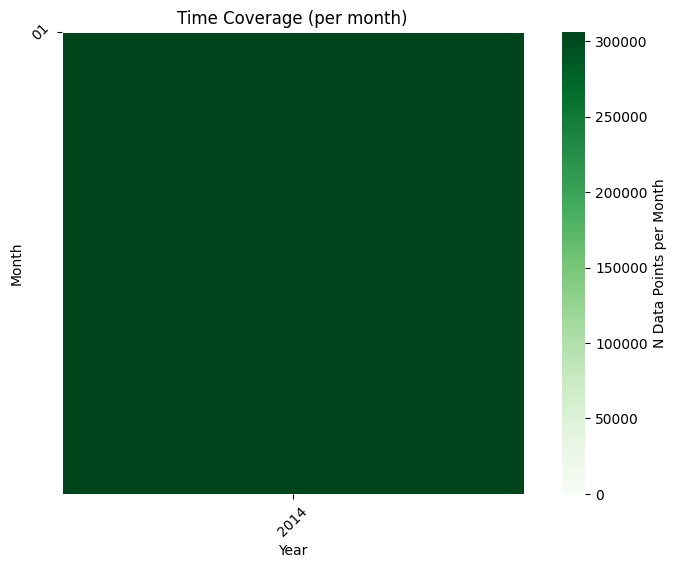

In [7]:
aodn_dataset.plot_time_coverage()

## Time Series at Key Wavelengths

The WetLabs AC-S measures spectral absorption `a(λ)` and attenuation `c(λ)` continuously at the Lucinda Jetty (-18.52 °S, 146.39 °E), 3 m depth. Three processing levels are available:

| Prefix | Description |
|---|---|
| `cal_data_*` | Calibrated only |
| `tsc_data_*` | + temperature & salinity correction (**recommended**) |
| `rtc_data_*` | + temperature & salinity + reflective tube correction |

Diagnostically important wavelengths:
- **440 nm** — dominated by CDOM and phytoplankton absorption (blue)
- **550 nm** — green reference channel; relatively low absorption, useful scattering proxy
- **675 nm** — near the chlorophyll-a absorption peak; key phytoplankton indicator


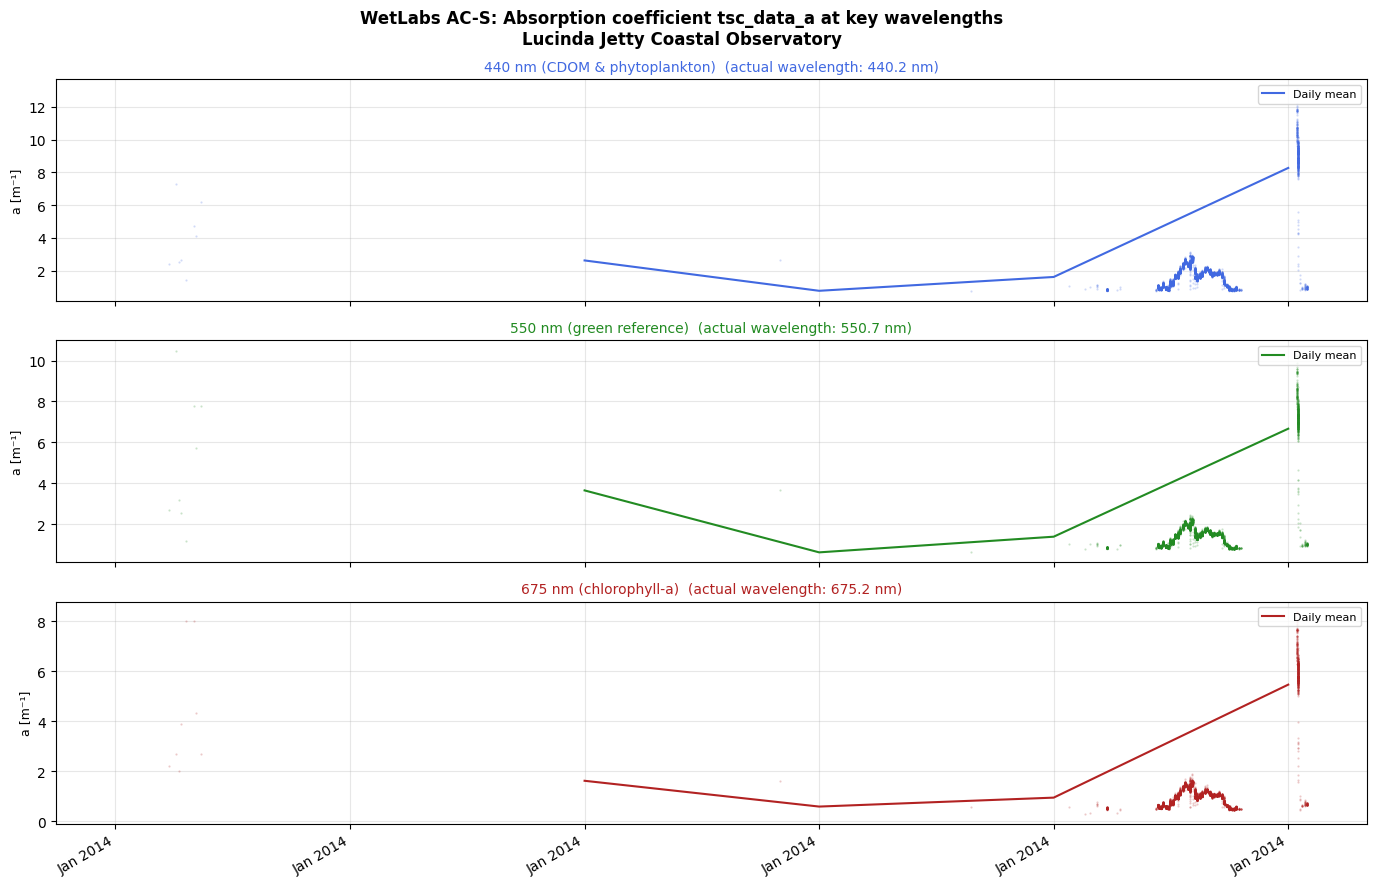

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

xds = aodn_dataset.zarr_store

# --- User parameters ---
DATE_START = '2014-01-01'
DATE_END   = '2018-12-31'
# -----------------------

ds_sub = xds.sel(TIME=slice(DATE_START, DATE_END))
wl_a   = xds['WAVELENGTH_a'].values
times  = pd.DatetimeIndex(ds_sub['TIME'].values)

wavelengths = {440: '440 nm (CDOM & phytoplankton)', 550: '550 nm (green reference)', 675: '675 nm (chlorophyll-a)'}
colors       = {440: 'royalblue', 550: 'forestgreen', 675: 'firebrick'}

fig, axes = plt.subplots(len(wavelengths), 1, figsize=(14, 9), sharex=True)

for ax, (target_wl, label) in zip(axes, wavelengths.items()):
    idx       = int(np.argmin(np.abs(wl_a - target_wl)))
    actual_wl = float(wl_a[idx])
    color     = colors[target_wl]

    a_raw = ds_sub['tsc_data_a'].isel(WAVELENGTH_a=idx).values
    qc    = ds_sub['tsc_data_a_quality_control'].isel(WAVELENGTH_a=idx).values
    a_qc  = np.where(qc <= 2, a_raw, np.nan)

    a_series = pd.Series(a_qc, index=times)
    daily    = a_series.resample('D').mean()

    ax.plot(times, a_qc, '.', markersize=1, color=color, alpha=0.25)
    ax.plot(daily.index, daily.values, color=color, linewidth=1.5, label='Daily mean')
    ax.set_ylabel('a [m⁻¹]', fontsize=9)
    ax.set_title(f'{label}  (actual wavelength: {actual_wl:.1f} nm)', fontsize=10, color=color)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=30)
fig.suptitle('WetLabs AC-S: Absorption coefficient tsc_data_a at key wavelengths\nLucinda Jetty Coastal Observatory', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Spectral Absorption Hovmöller Diagram

A Hovmöller diagram plots **wavelength on the y-axis** and **time on the x-axis**, with colour indicating the magnitude of the absorption coefficient `a(λ)`. This view reveals:

- Seasonal cycles in phytoplankton biomass (enhanced near-UV and red absorption in productive periods)
- CDOM input events (elevated short-wavelength absorption after rainfall / river runoff)
- Long-term trends in optical water quality

Each time step is collapsed to a **daily median** to reduce noise.


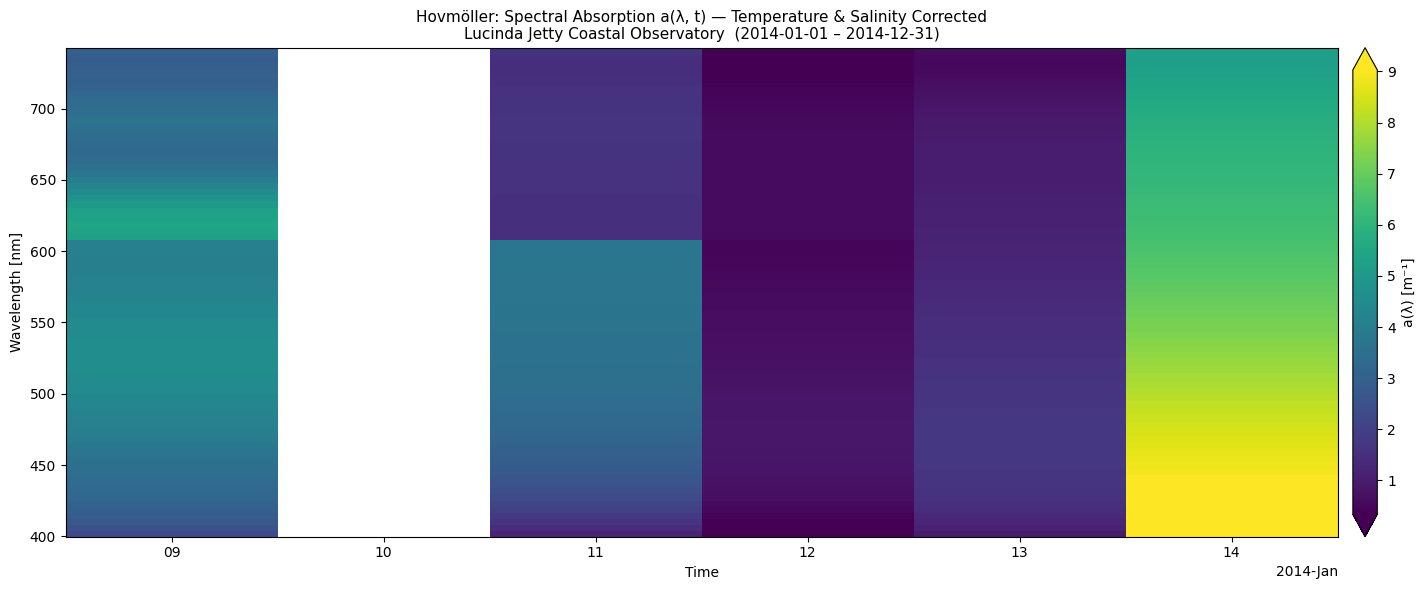

In [9]:
import matplotlib.pyplot as plt

xds = aodn_dataset.zarr_store

# --- User parameters ---
DATE_START = '2014-01-01'
DATE_END   = '2014-12-31'
# -----------------------

ds_sub = xds.sel(TIME=slice(DATE_START, DATE_END))

# QC-filter then resample to daily median using xarray natively
# (handles dimension order, datetime coords, and float types automatically)
a_da    = ds_sub['tsc_data_a'].where(ds_sub['tsc_data_a_quality_control'] <= 2)
a_daily = a_da.resample(TIME='1D').median('TIME')

fig, ax = plt.subplots(figsize=(16, 6))
a_daily.plot(
    x='TIME',
    y='WAVELENGTH_a',
    cmap='viridis',
    robust=True,                             # clips colour scale to 2nd–98th percentile
    ax=ax,
    cbar_kwargs={'label': 'a(λ) [m⁻¹]', 'pad': 0.01},
)
ax.set_xlabel('Time')
ax.set_ylabel('Wavelength [nm]')
ax.set_title(
    f'Hovmöller: Spectral Absorption a(λ, t) — Temperature & Salinity Corrected\n'
    f'Lucinda Jetty Coastal Observatory  ({DATE_START} – {DATE_END})',
    fontsize=11,
)
plt.tight_layout()
plt.show()


## Seasonal Mean Absorption and Attenuation Spectra

Averaging spectra by meteorological season reveals how the spectral shape of absorption `a(λ)` and attenuation `c(λ)` changes through the year — driven by:

- **Summer (DJF)**: higher temperature, potentially elevated phytoplankton and CDOM
- **Winter (JJA)**: cooler, clearer water; lower overall absorption
- **Autumn/Spring transition** (MAM/SON): intermediate conditions

Both absorption and attenuation use the temperature & salinity corrected (`tsc_data_*`) variables.


/tmp/ipykernel_3695042/4035930567.py:38: RuntimeWarning: Mean of empty slice
  mean_a  = np.nanmean(a_data[:, mask], axis=1)
/tmp/ipykernel_3695042/4035930567.py:39: RuntimeWarning: Mean of empty slice
  mean_c  = np.nanmean(c_data[:, mask], axis=1)


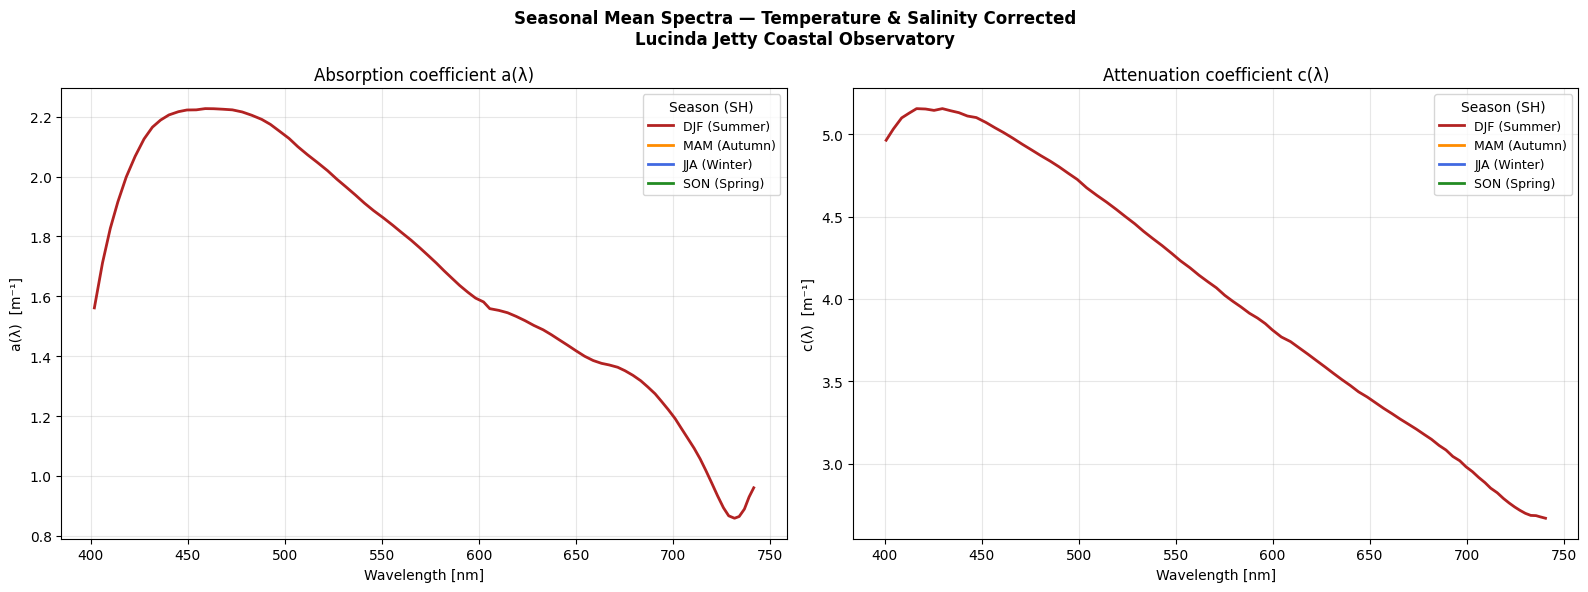

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

xds = aodn_dataset.zarr_store

# --- User parameters ---
DATE_START = '2014-01-01'
DATE_END   = '2024-12-31'
# -----------------------

ds_sub = xds.sel(TIME=slice(DATE_START, DATE_END))
wl_a   = xds['WAVELENGTH_a'].values
wl_c   = xds['WAVELENGTH_c'].values
times  = pd.DatetimeIndex(ds_sub['TIME'].values)

a_data = ds_sub['tsc_data_a'].values
c_data = ds_sub['tsc_data_c'].values
a_data = np.where(ds_sub['tsc_data_a_quality_control'].values <= 2, a_data, np.nan)
c_data = np.where(ds_sub['tsc_data_c_quality_control'].values <= 2, c_data, np.nan)

# Meteorological seasons (Southern Hemisphere)
season_map    = {12: 'DJF (Summer)', 1: 'DJF (Summer)', 2: 'DJF (Summer)',
                  3: 'MAM (Autumn)',  4: 'MAM (Autumn)',  5: 'MAM (Autumn)',
                  6: 'JJA (Winter)',  7: 'JJA (Winter)',  8: 'JJA (Winter)',
                  9: 'SON (Spring)', 10: 'SON (Spring)', 11: 'SON (Spring)'}
season_colors = {'DJF (Summer)': 'firebrick', 'MAM (Autumn)': 'darkorange',
                 'JJA (Winter)': 'royalblue',  'SON (Spring)': 'forestgreen'}
season_order  = ['DJF (Summer)', 'MAM (Autumn)', 'JJA (Winter)', 'SON (Spring)']

seasons = times.month.map(season_map)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for season in season_order:
    mask    = seasons == season
    color   = season_colors[season]
    mean_a  = np.nanmean(a_data[:, mask], axis=1)
    mean_c  = np.nanmean(c_data[:, mask], axis=1)
    ax1.plot(wl_a, mean_a, color=color, linewidth=2, label=season)
    ax2.plot(wl_c, mean_c, color=color, linewidth=2, label=season)

for ax, title, ylabel in [
    (ax1, 'Absorption coefficient a(λ)', 'a(λ)  [m⁻¹]'),
    (ax2, 'Attenuation coefficient c(λ)', 'c(λ)  [m⁻¹]'),
]:
    ax.set_xlabel('Wavelength [nm]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title='Season (SH)', fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Seasonal Mean Spectra — Temperature & Salinity Corrected\nLucinda Jetty Coastal Observatory', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Derived Scattering Coefficient b(λ) = c(λ) − a(λ)

The **scattering coefficient** is not directly measured by the AC-S but is derived as:

> **b(λ) = c(λ) − a(λ)**

Scattering is dominated by suspended particles (phytoplankton, non-algal particles, mineral sediments). At **550 nm**, where phytoplankton absorption is low, b(550) is a widely used proxy for total particulate load / turbidity.

> **Note**: WAVELENGTH_a and WAVELENGTH_c are slightly offset (~3 nm). b(λ) here uses the WAVELENGTH_a grid and pairs each wavelength index directly with the corresponding WAVELENGTH_c index — standard practice for AC-S data.


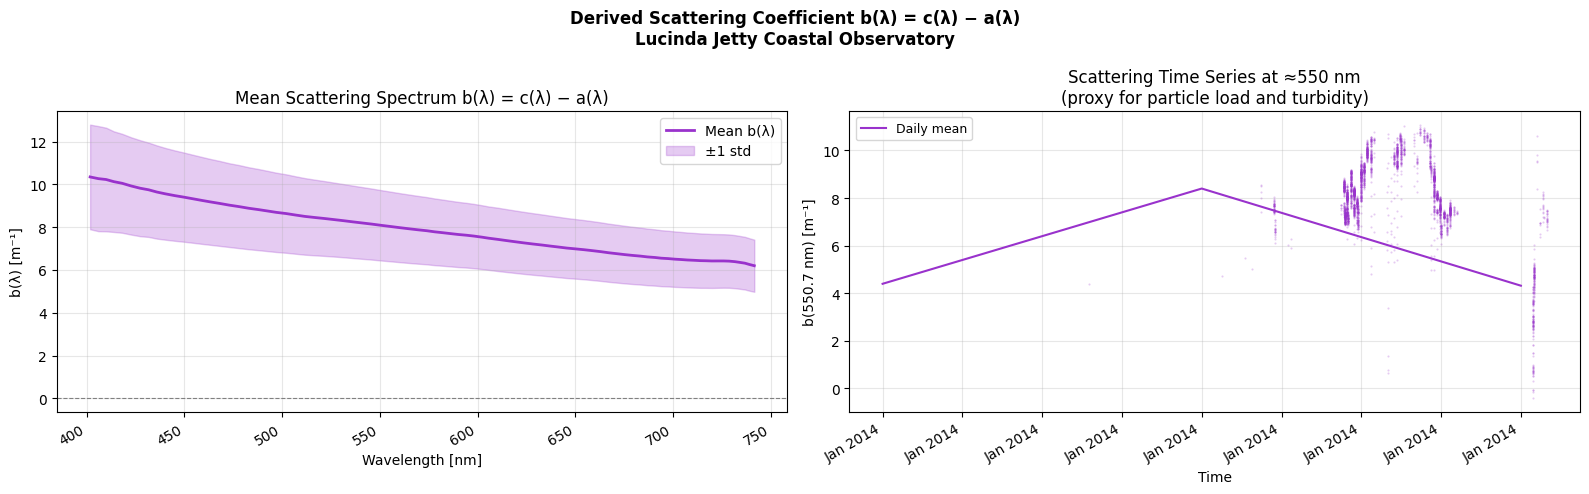

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

xds = aodn_dataset.zarr_store

# --- User parameters ---
DATE_START = '2014-01-01'
DATE_END   = '2014-12-31'
# -----------------------

ds_sub = xds.sel(TIME=slice(DATE_START, DATE_END))
wl_a   = xds['WAVELENGTH_a'].values
times  = pd.DatetimeIndex(ds_sub['TIME'].values)

a_data = ds_sub['tsc_data_a'].values
c_data = ds_sub['tsc_data_c'].values
good   = (ds_sub['tsc_data_a_quality_control'].values <= 2) & (ds_sub['tsc_data_c_quality_control'].values <= 2)
a_qc   = np.where(good, a_data, np.nan)
c_qc   = np.where(good, c_data, np.nan)
b      = c_qc - a_qc                            # scattering coefficient

b_mean = np.nanmean(b, axis=1)
b_std  = np.nanstd(b,  axis=1)

idx550    = int(np.argmin(np.abs(wl_a - 550)))
wl550     = float(wl_a[idx550])
b550      = pd.Series(b[idx550, :], index=times)
daily_b550 = b550.resample('D').mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: mean ± std spectrum
ax1.plot(wl_a, b_mean, color='darkorchid', linewidth=2, label='Mean b(λ)')
ax1.fill_between(wl_a, b_mean - b_std, b_mean + b_std, alpha=0.25, color='darkorchid', label='±1 std')
ax1.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Wavelength [nm]')
ax1.set_ylabel('b(λ) [m⁻¹]')
ax1.set_title('Mean Scattering Spectrum b(λ) = c(λ) − a(λ)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: time series at ~550 nm
ax2.plot(times, b[idx550, :], '.', markersize=1, color='darkorchid', alpha=0.25)
ax2.plot(daily_b550.index, daily_b550.values, color='darkorchid', linewidth=1.5, label='Daily mean')
ax2.set_xlabel('Time')
ax2.set_ylabel(f'b({wl550:.1f} nm) [m⁻¹]')
ax2.set_title(f'Scattering Time Series at ≈550 nm\n(proxy for particle load and turbidity)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.autofmt_xdate(rotation=30)
fig.suptitle('Derived Scattering Coefficient b(λ) = c(λ) − a(λ)\nLucinda Jetty Coastal Observatory', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
